# 14 — High-gamma numerical convergence check (gamma_ij=24)

The locked GPU/discretization parameters (`N_min=128`, `panels_per_oscillation=40`,
`wall_points=20`, `how_often_ds=5`) were only validated at `gamma_ij<=8`
(`AI_HANDOFF.md`'s "Locked GPU Filon convergence parameters"). This checks
whether they still hold at `gamma_ij=24`, via three checks:

1. **`N_min` + `panels_per_oscillation` together** (coupled -- `N_min` is a
   floor that only bites when the panels-per-oscillation criterion alone
   would give too few panels) -- pure CLI flags.
2. **`wall_points`** -- baked into the setup file at generation time.
3. **`how_often_ds`** -- also baked into the setup file. Tested by
   *decreasing* it (finer), not increasing -- higher `how_often_ds` means
   coarser sampling, the opposite semantics from the other two checks.

`baby_steps` is explicitly excluded.

**Important fix vs. the first version of this notebook**: `T_MAX` here is
the *pair's own* `1.4*R_*(gamma_ij=24)`, not the production-scan's
domain-shared `1.4*R_*(gamma_star_max)`. The original run (from
`11_high_gamma_probe.ipynb`) used the domain-shared value (`T_MAX=186.4`),
but gamma_ij=24 only collides at `t_first=166.3` -- so that run only ever
saw the pair ~20 time units after collision, barely evolved. That
domain-shared cutoff is the *correct* choice for the production scan (real
diagnostic data confirms high-gamma_ij pairs' geometric weight is genuinely
cut off that early by occlusion within a real realization -- see the
project history), but it is the *wrong* choice for a numerical-convergence
check, which needs to see the pair actually evolved, not freshly collided.
So every setup here is regenerated with the pair's own `R_*`.

Each check gets 4 runs. Rather than submitting a 13th job just for a new
baseline (locked `N_min=128, panels_per_oscillation=40, wall_points=20,
how_often_ds=5`, at the corrected `T_MAX`), the `how_often_ds` check's
4th slot (previously `how_often_ds=1`) is replaced by this baseline run --
same node, same 4 GPUs, and that run becomes the reference for all three
checks. 12 new jobs total, 3 nodes at 4 GPUs each.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import ptbuilder as pt
from ptbuilder.ic import BubbleMasterParams, write_2d_setup
from ptbuilder.weight_scan_diagnostics import load_kinematics

REPO_ROOT   = Path(pt.__file__).parent.parent
SCRIPTS_DIR = REPO_ROOT / 'scripts'
LOGS_DIR    = REPO_ROOT / 'logs'
SCRIPTS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

LAMBDA_BAR = 0.84

# gamma_ij=24 was originally chosen as 2.5*9.6 (a domain gamma_star_max=9.6)
# in 11_high_gamma_probe.ipynb -- kept here only as context for why 24, not
# used to compute T_MAX (see markdown above).
GAMMA_STAR_MAX_CONTEXT = 9.6
PAIR_GAMMA_FACTOR      = 2.5
GAMMA_IJ_TARGET        = 24
DT                     = 2

KR_MIN, KR_MAX = 1.0, 100.0
N_OMEGA = 32
N_K     = 51
TIME_FACTOR = 1.4

CUTOFF_TYPE = 0
BABY_STEPS  = 100   # locked, excluded from this check

# Locked production values -- the new baseline uses exactly these.
LOCKED = dict(n_min=128, ppw=40, wall_points=20, how_often_ds=5)

# New values for each check (baseline is the 4th how_often_ds slot, not a
# separate run -- see markdown above)
NMIN_PPW_JOINT    = [(160, 48), (192, 56), (256, 64), (320, 72)]
WALL_POINTS_NEW   = [24, 28, 32, 36]
HOW_OFTEN_DS_NEW  = [4, 3, 2]   # decreasing = finer; baseline (5) added separately

CHECK_ROOT  = REPO_ROOT / 'data/lb0.84_high_gamma_convergence_check'
setup_dir   = CHECK_ROOT / 'setups'
output_root = CHECK_ROOT / 'gpu'
setup_dir.mkdir(parents=True, exist_ok=True)
output_root.mkdir(parents=True, exist_ok=True)

instanton_path = REPO_ROOT / f'data/phi4_lambda_bar{LAMBDA_BAR:g}/instanton.h5'
kin = load_kinematics(instanton_path)


class CachedPhi4Potential:
    def __init__(self, lambda_bar):
        self.params = {'lambda_bar': float(lambda_bar)}

    def to_hdf5(self, group):
        group.attrs.create('type', 'phi4', dtype=h5py.string_dtype(encoding='ascii'))
        group.attrs['phi_false'] = 0.0
        group.attrs['phi_true']  = 1.0
        group.attrs['lambda_bar'] = self.params['lambda_bar']


model = SimpleNamespace(instanton=kin.profile, kinematics=kin,
                        potential=CachedPhi4Potential(LAMBDA_BAR))


def time_at_gamma(gamma):
    if gamma <= 1.0:
        return 0.0
    return brentq(lambda t: float(kin.Gamma(t)) - gamma, 0.0, 1.0e7)


def rstar_at_gamma(gamma):
    t = time_at_gamma(gamma)
    return 2.0 * float(kin.R(t, r='mid'))

## 1. gamma_ij=24 kinematics, using the pair's OWN R_*

`T_MAX = 1.4 * R_*(gamma_ij=24)`, not the domain-shared value -- see the
fix explained above.

In [2]:
R_STAR_OWN = rstar_at_gamma(GAMMA_IJ_TARGET)
T_MAX      = TIME_FACTOR * R_STAR_OWN
OMEGA_MIN  = KR_MIN / R_STAR_OWN

t_first = time_at_gamma(GAMMA_IJ_TARGET)
n_t     = int(np.ceil((T_MAX - t_first) / DT)) + 1
times   = np.linspace(t_first, T_MAX, n_t)

smallest_target = max(1.0, GAMMA_IJ_TARGET / PAIR_GAMMA_FACTOR)
omega_max = KR_MAX / rstar_at_gamma(smallest_target)
omega = np.geomspace(OMEGA_MIN, omega_max, N_OMEGA)

print(f'gamma_ij={GAMMA_IJ_TARGET}:  R_*={R_STAR_OWN:.3f}  t_first={t_first:.3f}  '
      f'T_MAX={T_MAX:.3f}  n_t={n_t}')
print(f'(for reference, the old domain-shared probe used T_MAX=186.402, n_t=12 -- '
      f'only {186.402 - t_first:.1f} time units past collision)')

gamma_ij=24:  R_*=332.884  t_first=166.297  T_MAX=466.037  n_t=151
(for reference, the old domain-shared probe used T_MAX=186.402, n_t=12 -- only 20.1 time units past collision)


## 2. Generate all setups (baseline-domain, wall_points variants, how_often_ds variants)

All at the corrected `T_MAX`/`times`/`omega` computed above.

In [3]:
def write_variant(wall_points, how_often_ds, name):
    params = BubbleMasterParams(
        dz=None, wall_points=wall_points,
        n_w=N_OMEGA, n_k=N_K, how_often_ds=how_often_ds,
        baby_steps=BABY_STEPS, cutoff_type=CUTOFF_TYPE, t_0_scal=1.0,
        collision_radius='mid',
    )
    setup_path = setup_dir / f'{name}.h5'
    write_2d_setup(model, GAMMA_IJ_TARGET, times, setup_path, params, wlist=omega)
    return setup_path


# Baseline-domain setup: ALL locked values, corrected T_MAX. Reused for the
# N_min/ppw check (pure CLI flags) AND as the how_often_ds check's 4th
# ("baseline") slot -- both are exactly this same setup + locked CLI flags.
baseline_setup = write_variant(LOCKED['wall_points'], LOCKED['how_often_ds'], 'g0024_baseline')
print(f'Written: {baseline_setup.relative_to(REPO_ROOT)}  (baseline-domain setup, n_t={n_t})')

new_setups = {'baseline': baseline_setup}
for wp in WALL_POINTS_NEW:
    new_setups[f'wallpoints_{wp}'] = write_variant(wp, LOCKED['how_often_ds'], f'g0024_wp{wp}')
for hods in HOW_OFTEN_DS_NEW:
    new_setups[f'hods_{hods}'] = write_variant(LOCKED['wall_points'], hods, f'g0024_hods{hods}')

for name, path in new_setups.items():
    if name != 'baseline':
        print(f'Written: {path.relative_to(REPO_ROOT)}')

Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_baseline.h5  (baseline-domain setup, n_t=151)
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp24.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp28.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp32.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp36.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods4.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods3.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods2.h5


## 3. Build the run manifest (12 new jobs, one of which is the new baseline)

In [4]:
manifest_rows = []   # (check, label, setup_rel, param, ppw, out_name)

for n_min, ppw in NMIN_PPW_JOINT:
    out_name = f'nminppw_{n_min}_{ppw}'
    manifest_rows.append(('n_min_ppw', f'N_min={n_min},ppw={ppw}',
                          baseline_setup.relative_to(REPO_ROOT), n_min, ppw, out_name))

for wp in WALL_POINTS_NEW:
    out_name = f'wallpoints_{wp}'
    manifest_rows.append(('wall_points', f'wall_points={wp}',
                          new_setups[f'wallpoints_{wp}'].relative_to(REPO_ROOT),
                          LOCKED['n_min'], LOCKED['ppw'], out_name))

for hods in HOW_OFTEN_DS_NEW:
    out_name = f'hods_{hods}'
    manifest_rows.append(('how_often_ds', f'how_often_ds={hods}',
                          new_setups[f'hods_{hods}'].relative_to(REPO_ROOT),
                          LOCKED['n_min'], LOCKED['ppw'], out_name))

# The new baseline: how_often_ds=5 (locked), same setup as N_min/ppw's --
# this is the 4th how_often_ds slot, replacing the old "how_often_ds=1" test.
BASELINE_NAME = 'hods_5_baseline'
manifest_rows.append(('how_often_ds', 'how_often_ds=5 (BASELINE, locked)',
                      baseline_setup.relative_to(REPO_ROOT),
                      LOCKED['n_min'], LOCKED['ppw'], BASELINE_NAME))

manifest = CHECK_ROOT / 'manifest.tsv'
manifest.write_text(
    'check\tlabel\tsetup\tparam\tppw\tname\n' +
    ''.join(f'{c}\t{l}\t{s}\t{p}\t{w}\t{n}\n' for c, l, s, p, w, n in manifest_rows)
)
print(f'{len(manifest_rows)} new runs written to {manifest.relative_to(REPO_ROOT)}')
for row in manifest_rows:
    print(' ', row)

12 new runs written to data/lb0.84_high_gamma_convergence_check/manifest.tsv
  ('n_min_ppw', 'N_min=160,ppw=48', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_baseline.h5'), 160, 48, 'nminppw_160_48')
  ('n_min_ppw', 'N_min=192,ppw=56', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_baseline.h5'), 192, 56, 'nminppw_192_56')
  ('n_min_ppw', 'N_min=256,ppw=64', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_baseline.h5'), 256, 64, 'nminppw_256_64')
  ('n_min_ppw', 'N_min=320,ppw=72', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_baseline.h5'), 320, 72, 'nminppw_320_72')
  ('wall_points', 'wall_points=24', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_wp24.h5'), 128, 40, 'wallpoints_24')
  ('wall_points', 'wall_points=28', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_wp28.h5'), 128, 40, 'wallpoints_28')
  ('wall_points', 'wall_points=32', PosixPath('data/lb0.84_high_gamma_conve

## 4. Generate SLURM scripts -- 3 INDEPENDENT one-node jobs

Each check is its own single-node, 4-GPU job -- can start as soon as its own
node is free, rather than waiting on the others.

In [5]:
GPU_ACCOUNT      = 'm3166_g'
GPU_S_BATCH_SIZE = 128
GPU_WALLTIME     = '04:00:00'   # generous -- baseline at gamma_ij=24 was ~77 min at
                                # the (too-short) domain-shared T_MAX; the corrected,
                                # much longer T_MAX here will take substantially more

manifest_rel = manifest.relative_to(REPO_ROOT)

script_paths = {}
for check in ('n_min_ppw', 'wall_points', 'how_often_ds'):
    rows = [r for r in manifest_rows if r[0] == check]
    script_path = SCRIPTS_DIR / f'lb0.84_high_gamma_convergence_check_{check}_gpu.sh'
    script_path.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_hg_{check}
#SBATCH --output={LOGS_DIR.relative_to(REPO_ROOT)}/bm_hg_{check}_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A {GPU_ACCOUNT}
#SBATCH --nodes=1
#SBATCH --ntasks=4
#SBATCH --ntasks-per-node=4
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time={GPU_WALLTIME}
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
pids=()
while IFS=$'\\t' read -r check_col label setup param ppw name; do
    [[ "$check_col" != "{check}" ]] && continue
    output="{output_root.relative_to(REPO_ROOT)}/${{name}}"
    mkdir -p "$output"
    /usr/bin/time --verbose srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu "$setup" "$output/" --param "$param" --filon-panels-per-osc "$ppw" --s-batch-size {GPU_S_BATCH_SIZE} &
    pids+=("$!")
done < {manifest_rel}
status=0
for pid in "${{pids[@]}}"; do
    wait "$pid" || status=1
done
exit "$status"
''')
    script_path.chmod(0o755)
    script_paths[check] = script_path
    print(f'Written: {script_path.relative_to(REPO_ROOT)}  ({len(rows)} tasks)')

print()
print('Submit all three independently:')
for check, sp in script_paths.items():
    print(f'  sbatch {sp.relative_to(REPO_ROOT)}')

Written: scripts/lb0.84_high_gamma_convergence_check_n_min_ppw_gpu.sh  (4 tasks)
Written: scripts/lb0.84_high_gamma_convergence_check_wall_points_gpu.sh  (4 tasks)
Written: scripts/lb0.84_high_gamma_convergence_check_how_often_ds_gpu.sh  (4 tasks)

Submit all three independently:
  sbatch scripts/lb0.84_high_gamma_convergence_check_n_min_ppw_gpu.sh
  sbatch scripts/lb0.84_high_gamma_convergence_check_wall_points_gpu.sh
  sbatch scripts/lb0.84_high_gamma_convergence_check_how_often_ds_gpu.sh


## 5. Load results -- compare each check against the new baseline

Baseline = `hods_5_baseline` (locked `N_min=128, panels_per_oscillation=40,
wall_points=20, how_often_ds=5`, at the corrected `T_MAX`) -- part of the
`how_often_ds` job, not a separate run. Reports "NOT READY" gracefully until
synced from the cluster.

In [6]:
I_T = -1   # which cutoff to compare -- -1 = last (most time-saturated)


def load_spectrum(out_dir, i_t=I_T):
    files = sorted(Path(out_dir).glob('result_*.h5'), key=lambda p: int(p.stem.split('_')[1]))
    if not files:
        raise FileNotFoundError(f'No result_*.h5 in {out_dir}')
    with h5py.File(files[i_t]) as f:
        t = f.attrs['t'] if 't' in f.attrs else None
        return f['w'][:], f['spectrum'][:], t


def rel_diff(ref, test, floor_frac=0.01):
    peak = np.abs(ref).max()
    mask = np.abs(ref) >= floor_frac * peak
    if not mask.any():
        return np.array([])
    return (test[mask] - ref[mask]) / ref[mask]


BASELINE_OUTPUT = output_root / BASELINE_NAME

try:
    w_ref, spec_ref, t_ref = load_spectrum(BASELINE_OUTPUT)
    t_ref_str = f'{t_ref:.3f}' if t_ref is not None else f'{times[I_T]:.3f} (from setup; result predates the t-attribute fix)'
    print(f'Baseline loaded: {BASELINE_OUTPUT.relative_to(REPO_ROOT)}  (t={t_ref_str})')
except FileNotFoundError as e:
    w_ref = spec_ref = None
    print(f'Baseline NOT READY: {e}')

by_check = {'n_min_ppw': [], 'wall_points': [], 'how_often_ds': []}

print()
print(f"{'check':>14}  {'label':>26}  {'max % vs baseline':>18}  {'mean %':>8}")
print('-' * 74)
for check, label, setup_rel, param, ppw, name in manifest_rows:
    if name == BASELINE_NAME:
        continue   # baseline is the reference, not compared against itself
    out_dir = output_root / name
    try:
        w_test, spec_test, _ = load_spectrum(out_dir)
        by_check[check].append((label, w_test, spec_test))
        if spec_ref is None:
            print(f"{check:>14}  {label:>26}  {'(no baseline)':>18}")
            continue
        spec_test_i = np.interp(w_ref, w_test, spec_test)
        rd = rel_diff(spec_ref, spec_test_i)
        m = np.abs(rd).max() * 100 if rd.size else float('nan')
        a = np.abs(rd).mean() * 100 if rd.size else float('nan')
        print(f"{check:>14}  {label:>26}  {m:>18.4f}  {a:>8.4f}")
    except FileNotFoundError:
        print(f"{check:>14}  {label:>26}  {'NOT READY':>18}")

Baseline NOT READY: No result_*.h5 in /Users/malte/Simulations/PhaseTransitionBuilder/data/lb0.84_high_gamma_convergence_check/gpu/hods_5_baseline

         check                       label   max % vs baseline    mean %
--------------------------------------------------------------------------
     n_min_ppw            N_min=160,ppw=48           NOT READY
     n_min_ppw            N_min=192,ppw=56           NOT READY
     n_min_ppw            N_min=256,ppw=64           NOT READY
     n_min_ppw            N_min=320,ppw=72           NOT READY
   wall_points              wall_points=24           NOT READY
   wall_points              wall_points=28           NOT READY
   wall_points              wall_points=32           NOT READY
   wall_points              wall_points=36           NOT READY
  how_often_ds              how_often_ds=4           NOT READY
  how_often_ds              how_often_ds=3           NOT READY
  how_often_ds              how_often_ds=2           NOT READY


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


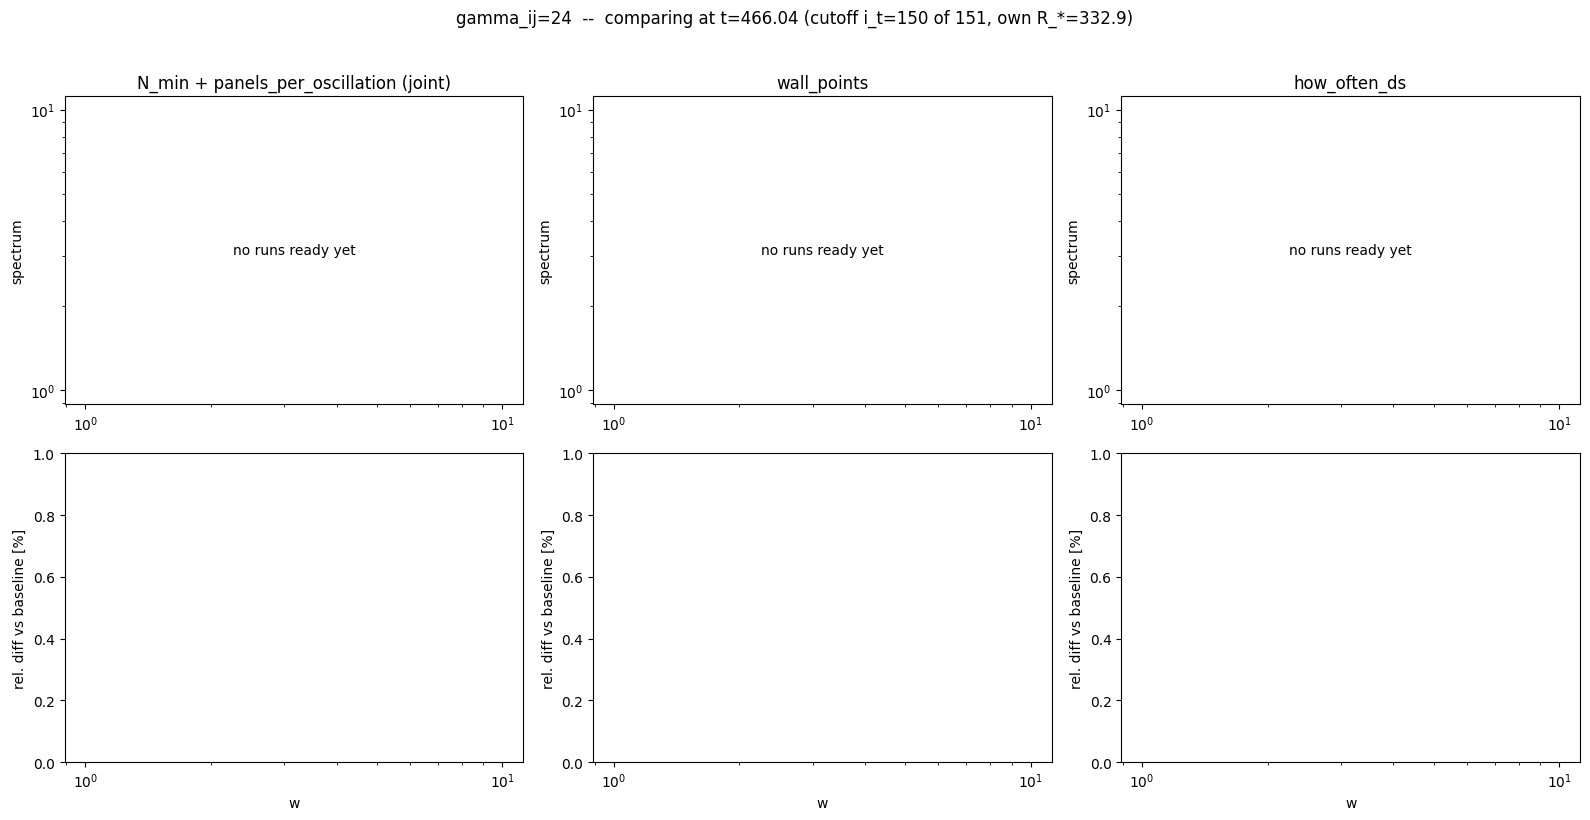

In [7]:
CHECK_TITLES = {
    'n_min_ppw':    'N_min + panels_per_oscillation (joint)',
    'wall_points':  'wall_points',
    'how_often_ds': 'how_often_ds',
}
COLORS4 = ['C0', 'C1', 'C2', 'C3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)

for col, check in enumerate(('n_min_ppw', 'wall_points', 'how_often_ds')):
    ax_spec, ax_diff = axes[0, col], axes[1, col]
    entries = by_check[check]

    if spec_ref is not None:
        ax_spec.plot(w_ref, spec_ref, color='k', lw=2.2, label='baseline (locked)')

    if not entries:
        ax_spec.text(0.5, 0.5, 'no runs ready yet', ha='center', va='center',
                    transform=ax_spec.transAxes)
    for (label, w_test, spec_test), color in zip(entries, COLORS4):
        ax_spec.plot(w_test, spec_test, lw=1.4, ls='--', color=color, label=label)
        if spec_ref is not None:
            spec_test_i = np.interp(w_ref, w_test, spec_test)
            rd = (spec_test_i - spec_ref) / np.where(spec_ref != 0, spec_ref, np.nan)
            ax_diff.plot(w_ref, rd * 100, lw=1.4, color=color, label=label)

    ax_spec.set_xscale('log'); ax_spec.set_yscale('log')
    ax_spec.set_title(CHECK_TITLES[check])
    ax_spec.set_ylabel('spectrum')
    ax_spec.legend(frameon=False, fontsize=7)

    ax_diff.axhline(0, color='0.6', lw=0.8, ls=':')
    ax_diff.set_xscale('log')
    ax_diff.set_xlabel('w')
    ax_diff.set_ylabel('rel. diff vs baseline [%]')
    ax_diff.legend(frameon=False, fontsize=7)

_t_title = t_ref if (spec_ref is not None and t_ref is not None) else times[I_T]
fig.suptitle(f'gamma_ij={GAMMA_IJ_TARGET}  --  comparing at t={_t_title:.2f} '
            f'(cutoff i_t={I_T if I_T>=0 else n_t+I_T} of {n_t}, own R_*={R_STAR_OWN:.1f})', y=1.02)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'high_gamma_convergence_check.pdf', bbox_inches='tight')
plt.show()